---
# CNN : `MNIST` (avec `Keras`)
---

## Packages

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from keras import callbacks, layers, models
from keras.datasets import mnist

---
## 1. Données
---

### 1.1. Importation

In [2]:
test_portion  = 1/5

(X_train_valid, y_train_valid), (X_test, y_test) = mnist.load_data()

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=test_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (48000, 28, 28)
Dimensions de X_valid : (12000, 28, 28)
Dimensions de X_test  : (10000, 28, 28)
Dimensions de y_train : (48000,)
Dimensions de y_valid : (12000,)
Dimensions de y_test  : (10000,)


### 1.2. Graphiques

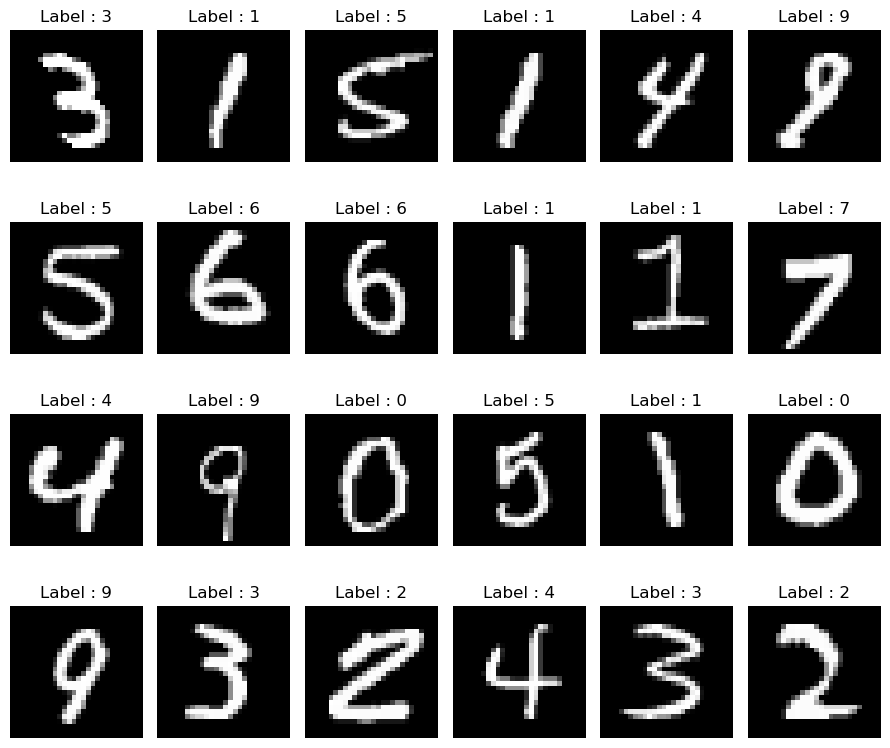

In [3]:
n_row = 4
n_col = 6
n = n_row * n_col

images = X_train[:n]
labels = y_train[:n]

fig, axes = plt.subplots(n_row, n_col, figsize=(1.5 * n_col, 2 * n_row))
for i in range(n):
    ax = axes[i//n_col, i%n_col]
    ax.imshow(images[i], cmap='gray')
    ax.set_title(f'Label : {labels[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### 1.3. Normalisation

In [4]:
X_train_norm = X_train / 255
X_valid_norm = X_valid / 255
X_test_norm  = X_test  / 255

---
## 2. CNN
---

### 2.1. Architecture

In [5]:
dim_inputs  = (28, 28, 1)
dim_outputs = 10

n_conv_1 = 8
n_conv_2 = 16

n_units_hl = 100

dropout_conv1 = 0.2
dropout_conv2 = 0.2
dropout_hl    = 0.2

model = models.Sequential(name='CNN')

model.add(layers.Input(shape=dim_inputs))

model.add(layers.Conv2D(filters=n_conv_1, kernel_size=(3, 3), activation='relu', name='Convolutive_1'))
model.add(layers.Dropout(rate=dropout_conv1, name='Dropout_Convolution_1'))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2, name='Max_pooling_1'))

model.add(layers.Conv2D(filters=n_conv_2, kernel_size=(3, 3), name='Convolutive_2', activation='relu'))
model.add(layers.Dropout(rate=dropout_conv2, name='Dropout_Convolution_2'))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2, name='Max_pooling_2'))

model.add(layers.Flatten())

model.add(layers.Dense(units=n_units_hl, activation='relu', name='Hidden_layer'))
model.add(layers.Dropout(rate=dropout_hl, name='Dropout_Hidden_layer'))

model.add(layers.Dense(units=dim_outputs, activation='softmax'))

model.summary()

Model: "CNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Convolutive_1 (Conv2D)      (None, 26, 26, 8)         80        
                                                                 
 Dropout_Convolution_1 (Dro  (None, 26, 26, 8)         0         
 pout)                                                           
                                                                 
 Max_pooling_1 (MaxPooling2  (None, 13, 13, 8)         0         
 D)                                                              
                                                                 
 Convolutive_2 (Conv2D)      (None, 11, 11, 16)        1168      
                                                                 
 Dropout_Convolution_2 (Dro  (None, 11, 11, 16)        0         
 pout)                                                           
                                                               

### 2.2. Optimiseur

In [6]:
model.compile(optimizer = 'adam',
              loss      = 'sparse_categorical_crossentropy',
              metrics   = ['accuracy'])

callback = callbacks.EarlyStopping(monitor              = 'val_loss',
                                   mode                 = 'min',
                                   patience             = 5,
                                   restore_best_weights = True)

### 2.3. Entraînement

In [7]:
hist = model.fit(X_train_norm,
                 y_train,
                 batch_size      = 300,
                 epochs          = 50,
                 validation_data = (X_valid_norm, y_valid),
                 callbacks       = [callback],
                 verbose         = 1)

Epoch 1/50
160/160 [==============================] - 2s 9ms/step - loss: 0.6816 - accuracy: 0.7939 - val_loss: 0.2288 - val_accuracy: 0.9501
Epoch 2/50
160/160 [==============================] - 1s 9ms/step - loss: 0.1801 - accuracy: 0.9462 - val_loss: 0.1356 - val_accuracy: 0.9681
Epoch 3/50
160/160 [==============================] - 1s 9ms/step - loss: 0.1300 - accuracy: 0.9601 - val_loss: 0.1077 - val_accuracy: 0.9737
Epoch 4/50
160/160 [==============================] - 2s 9ms/step - loss: 0.1088 - accuracy: 0.9660 - val_loss: 0.0945 - val_accuracy: 0.9776
Epoch 5/50
160/160 [==============================] - 1s 9ms/step - loss: 0.0943 - accuracy: 0.9707 - val_loss: 0.0883 - val_accuracy: 0.9778
Epoch 6/50
160/160 [==============================] - 2s 9ms/step - loss: 0.0855 - accuracy: 0.9731 - val_loss: 0.0744 - val_accuracy: 0.9801
Epoch 7/50
160/160 [==============================] - 2s 10ms/step - loss: 0.0769 - accuracy: 0.9759 - val_loss: 0.0649 - val_accuracy: 0.9830
Epoch

### 2.4. Prévisions

In [8]:
y_test_pred = model.predict(X_test_norm)
y_test_pred[0:5]

313/313 [==============================] - 1s 2ms/step


array([[1.63042529e-07, 3.26349635e-07, 5.35260085e-07, 2.93605490e-06,
        9.59941758e-07, 1.40788279e-08, 1.12481406e-10, 9.99992847e-01,
        1.32353479e-08, 2.19573849e-06],
       [3.04255855e-06, 3.17896556e-05, 9.99963164e-01, 4.41882264e-08,
        1.75039307e-08, 4.37612967e-12, 9.89594810e-07, 8.34961877e-09,
        1.04241519e-06, 3.32719408e-10],
       [1.49298398e-06, 9.99888539e-01, 6.33120999e-06, 5.82842965e-08,
        6.45424443e-05, 4.39342699e-07, 8.44626356e-06, 2.40263598e-05,
        5.50402501e-06, 5.74665819e-07],
       [9.98992145e-01, 8.18957346e-08, 3.92356451e-05, 8.29336273e-07,
        1.62693948e-04, 1.33172830e-06, 4.63831588e-04, 1.28889292e-06,
        2.60239426e-06, 3.36001074e-04],
       [3.90081070e-08, 2.84785262e-08, 1.49169797e-08, 1.89104843e-09,
        9.99955654e-01, 1.89207316e-09, 1.86630274e-07, 1.63291429e-06,
        1.09299117e-06, 4.15170871e-05]], dtype=float32)

In [9]:
y_test_pred_classes = np.argmax(y_test_pred, axis=1)
y_test_pred_classes[0:5]

array([7, 2, 1, 0, 4])

In [10]:
score_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f'Entropie test   : {score_test[0]:4.4f}')
print(f'Exactitude test : {score_test[1]:4.4f}')

Entropie test   : 0.0299
Exactitude test : 0.9905
